# Black-Derman-Toy model 

The BDT model was introduced in 1990 by Fischer Black, Emanuel Derman, and William Toy. It was one of the first no-arbitrage binomial models for interest rate dynamics.

The model was designed to:
- Capture the evolution of the short-term interest rate.
- Be consistent with the observed yield curve.
- Allow for a flexible term structure of volatility.

### Mathematical Formulation

The BDT model assumes that the short-term rate $r_t$ follows a binomial tree where:
$$r_{i+1}^{(up)} = r_i e^{\sigma_i}$$
$$r_{i+1}^{(down)} = r_i e^{-\sigma_i}$$
where:
- $r_i$ = short rate at node i.
- $\sigma_i$ = time-dependent volatility (ensures consistency with market data).
- The tree is recombinant, meaning that different paths leading to the same point result in the same rate.

### Risk-Neutral Probability

In a risk-neutral world, the probability p of an upward movement is given by:
$$p = \frac{e^{r_i \Delta t} - d}{u - d}$$
where:
- $u = e^{\sigma_i \sqrt{\Delta t}}$
- $d = e^{-\sigma_i \sqrt{\Delta t}}$

### Bond price
The bond price at each node is computed using:
$$P_i = \frac{p P_{i+1}^{(up)} + (1 - p) P_{i+1}^{(down)}}{e^{r_i \Delta t}}$$
where $P_{i+1}$ is the bond price at the next step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def build_bdt_tree(r0, sigma, n, dt):
    """
    Constructs a binomial tree for the Black-Derman-Toy (BDT) model.

    Parameters:
    - r0: Initial short rate.
    - sigma: List of volatilities for each time step.
    - n: Number of time steps.
    - dt: Time step size.

    Returns:
    - Tree of short rates.
    """
    tree = np.zeros((n, n))
    tree[0, 0] = r0  # Initial rate
    
    for i in range(1, n):
        for j in range(i + 1):
            tree[j, i] = r0 * np.exp(sigma[i-1] * (2 * j - i) * np.sqrt(dt))

    return tree

# Parameters
n = 10       # Number of steps
dt = 1       # Time step (in years)
r0 = 0.05    # Initial short rate
sigma = [0.02] * (n - 1)  # Constant volatility for simplicity

# Build the Tree
bdt_tree = build_bdt_tree(r0, sigma, n, dt)

# Display Tree
for i in range(n):
    print(f"Time {i}: {bdt_tree[:i+1, i]}")

Time 0: [0.05]
Time 1: [0.04900993 0.05101007]
Time 2: [0.04803947 0.05       0.05204054]
Time 3: [0.04708823 0.04900993 0.05101007 0.05309183]
Time 4: [0.04615582 0.04803947 0.05       0.05204054 0.05416435]
Time 5: [0.04524187 0.04708823 0.04900993 0.05101007 0.05309183 0.05525855]
Time 6: [0.04434602 0.04615582 0.04803947 0.05       0.05204054 0.05416435
 0.05637484]
Time 7: [0.04346791 0.04524187 0.04708823 0.04900993 0.05101007 0.05309183
 0.05525855 0.05751369]
Time 8: [0.04260719 0.04434602 0.04615582 0.04803947 0.05       0.05204054
 0.05416435 0.05637484 0.05867554]
Time 9: [0.04176351 0.04346791 0.04524187 0.04708823 0.04900993 0.05101007
 0.05309183 0.05525855 0.05751369 0.05986087]


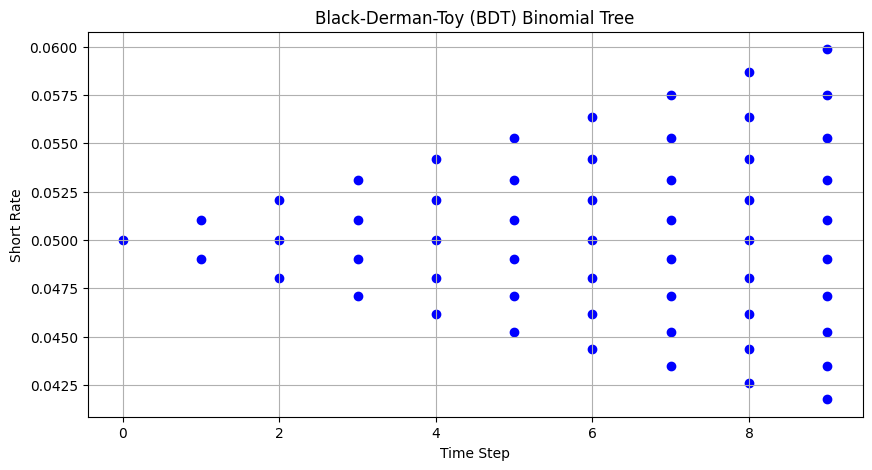

In [3]:
# Plot BDT Tree
plt.figure(figsize=(10, 5))
for i in range(n):
    plt.scatter([i] * (i + 1), bdt_tree[:i+1, i], color='blue')
plt.xlabel("Time Step")
plt.ylabel("Short Rate")
plt.title("Black-Derman-Toy (BDT) Binomial Tree")
plt.grid()
plt.show()

### Pricing a bond

In [4]:
def price_bond(bdt_tree, face_value, n, dt):
    """
    Prices a zero-coupon bond using the BDT tree.
    
    Parameters:
    - bdt_tree: Tree of short rates.
    - face_value: Bond face value.
    - n: Number of time steps.
    - dt: Time step size.

    Returns:
    - Bond price.
    """
    bond_prices = np.zeros((n, n))
    bond_prices[:, -1] = face_value  # Maturity payoff

    for i in range(n - 2, -1, -1):
        for j in range(i + 1):
            r = bdt_tree[j, i]
            discount_factor = np.exp(-r * dt)
            bond_prices[j, i] = discount_factor * 0.5 * (bond_prices[j, i+1] + bond_prices[j+1, i+1])

    return bond_prices[0, 0]

# Price a 10-year zero-coupon bond
bond_price = price_bond(bdt_tree, 100, n, dt)
print(f"Zero-coupon bond price: {bond_price:.2f}")

Zero-coupon bond price: 63.75
